![image.png](https://i.imgur.com/a3uAqnb.png)

# **Hard Hat Workers Object Detection with YOLOv8**
In this lab, we will:
✅ **Use YOLOv8** for **Hard Hat Workers detection**  
✅ **Understand the dataset structure**  
✅ **Train a YOLOv8 model**  
✅ **Evaluate the model on the validation set**  
✅ **Run inference on test images**  

---

## **1️⃣ Understanding the Dataset Structure**
The dataset follows the **YOLO format**, which consists of:
📂 **train/** → Training images & labels  
📂 **valid/** → Validation images & labels  
📂 **test/** → Test images (for inference)  
📜 **data.yaml** → Defines dataset paths & class names  

### **🔹 YOLO Dataset Folder Structure**
```
drone_dataset/
│── train/
│   │── images/
│   │   ├── 005298_jpg.rf.647d148af5d961d8bbc041f172247170.jpg
│   │   ├── 005304_jpg.rf.68023ed553bb1d711826d6e1f185ea39.jpg
│   │   ├── ...
│   │── labels/
│   │   ├── 005298_jpg.rf.647d148af5d961d8bbc041f172247170.txt
│   │   ├── 005304_jpg.rf.68023ed553bb1d711826d6e1f185ea39.txt
│   │   ├── ...
│
│── test/
│   │── images/
│   │   ├── 000001_jpg.rf.fddb09e33a544e332617f8ceb53ee805.jpg
│   │   ├── 000002_jpg.rf.85b55e30b8ce745e3c16966991a38018.jpg
│   │   ├── ...
│   │── labels/
│   │   ├── 000001_jpg.rf.fddb09e33a544e332617f8ceb53ee805.txt
│   │   ├── 000002_jpg.rf.85b55e30b8ce745e3c16966991a38018.txt
│   │   ├── ...
│
│── data.yaml
```
Each **image** has a **corresponding label** file with the **same name**, but a `.txt` extension.

---

## **2️⃣ What’s Inside a YOLO Label File?**
Each `.txt` file contains **annotations** in this format:

```
<class_id> <x_center> <y_center> <width> <height>
```

✅ **All values are normalized** between **0 and 1**  
✅ The **bounding box** is defined by its **center** and **size**  

### **🔹 Example (`000001_jpg.rf.fddb09e33a544e332617f8ceb53ee805 000002_jpg.rf.85b55e30b8ce745e3c16966991a38018.txt`)**
```
1 0.408 0.30266666666666664 0.104 0.15733333333333333
1 0.245 0.424 0.046 0.08
```
- **First column** → Class ID (`0` = head, `1` = helmet, `2` = person)  
- **Rest** → Bounding box (normalized)  

---

## **3️⃣ Loading the Dataset**

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hebaomer/hardhat-dataset")

print("Path to dataset files:", path)

100%|██████████| 408M/408M [00:19<00:00, 22.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/hebaomer/hardhat-dataset/versions/1


In [2]:
# Load dataset configuration
dataset_path = path + "/HardHat_Dataset/data.yaml"

# Check dataset information
print(open(dataset_path).read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names: ['head', 'helmet', 'person']

roboflow:
  workspace: heba-bv9kk
  project: saip-twxkl
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/heba-bv9kk/saip-twxkl/dataset/1


## **4️⃣ Training a YOLOv8 Model**
We will fine-tune a **pretrained YOLOv8 model**.

In [3]:
# Install Ultralytics library which has Yolo
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 56.9 MB/s eta 0:00:00


In [4]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
# Load YOLOv8 model (small version)
model = YOLO("yolov8s.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


#### Let's try to predict an image before training


image 1/1 /root/.cache/kagglehub/datasets/hebaomer/hardhat-dataset/versions/1/HardHat_Dataset/test/images/000028_jpg.rf.a35457c9451a75a225bba5ae5cf013e0.jpg: 640x640 7 persons, 1 snowboard, 16.6ms
Speed: 7.9ms preprocess, 16.6ms inference, 351.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


Text(0.5, 1.0, 'Predicted Image')

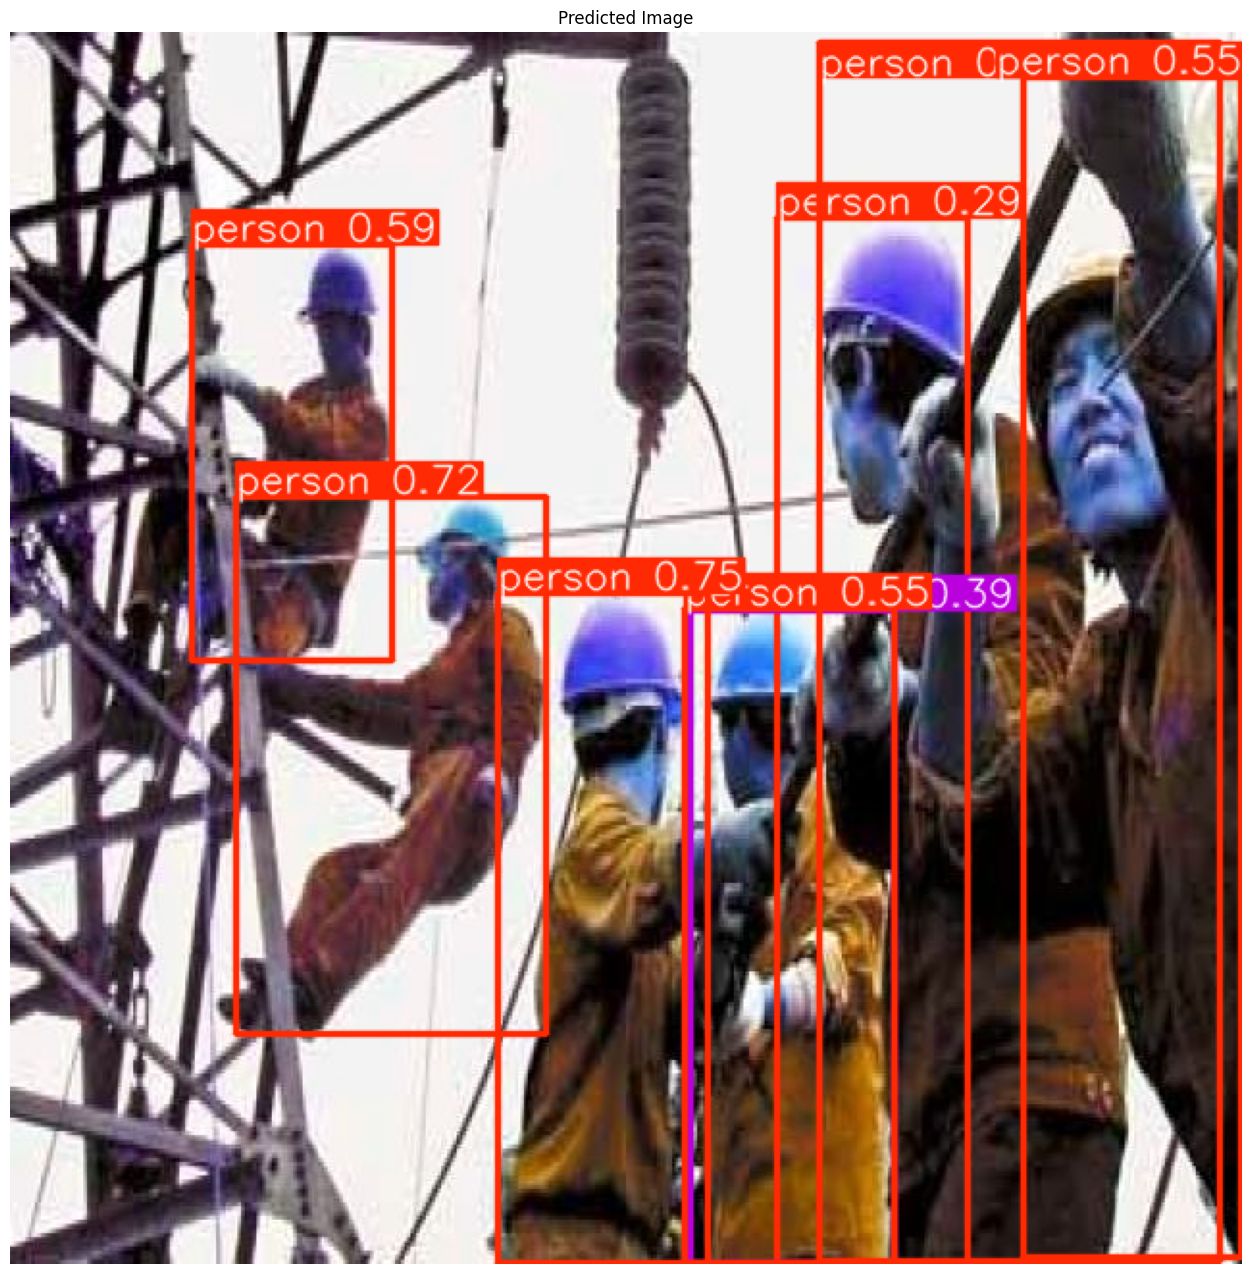

In [5]:
# Load an image and run inference
results = model(path + '/HardHat_Dataset/test/images/000028_jpg.rf.a35457c9451a75a225bba5ae5cf013e0.jpg', save=True)

# Convert result to a NumPy array and display
predicted_image = results[0].plot()  # Convert prediction to an image

plt.figure(figsize=(16, 16))
plt.imshow(predicted_image)
plt.axis("off")
plt.title("Predicted Image")

#### Nevermind, let's train it! 🚀

In [6]:
model.train(data=dataset_path, epochs=10, imgsz=400)

Ultralytics 8.3.200 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/hebaomer/hardhat-dataset/versions/1/HardHat_Dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=400, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ove

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c8ad3fe4650>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

## **5️⃣ Evaluating the Model**
We use **mAP@0.5:0.95** to assess performance.

In [9]:
# Run validation
metrics = model.val(data=dataset_path)

Ultralytics 8.3.200 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1296.7±508.1 MB/s, size: 49.2 KB)
val: Scanning /root/.cache/kagglehub/datasets/hebaomer/hardhat-dataset/versions/1/HardHat_Dataset/valid/labels.cache... 1055 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1055/1055 1.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 66/66 6.1it/s 10.9s
                   all       1055       3967      0.961      0.618      0.657      0.455
                  head        189        999      0.926       0.92      0.951      0.659
                helmet        968       2903      0.956      0.934      0.979      0.682
                person         26         65          1          0     0.0402     0.0245
Speed: 0.4ms preprocess, 4.1ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/runs/detect/val


## **6️⃣ Running Inference on Test Images**



image 1/1 /root/.cache/kagglehub/datasets/hebaomer/hardhat-dataset/versions/1/HardHat_Dataset/test/images/000028_jpg.rf.a35457c9451a75a225bba5ae5cf013e0.jpg: 416x416 6 helmets, 10.2ms
Speed: 2.0ms preprocess, 10.2ms inference, 1.5ms postprocess per image at shape (1, 3, 416, 416)
Results saved to /content/runs/detect/predict2


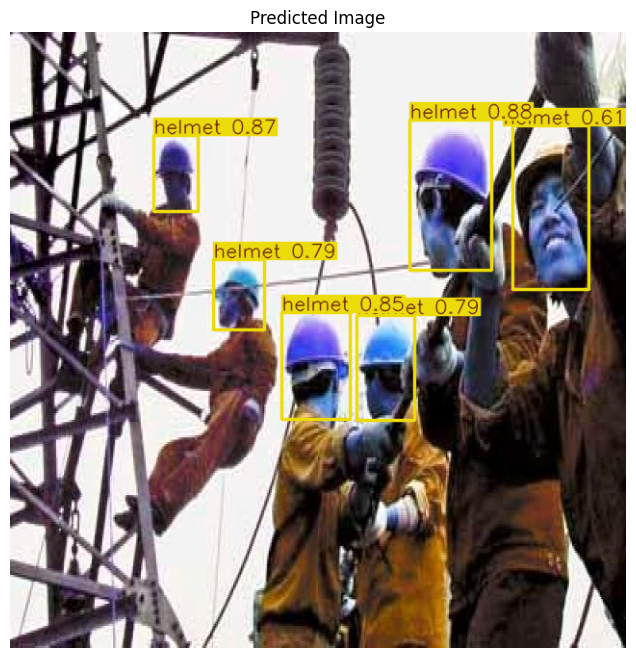

In [12]:
# Load an image and run inference
model = YOLO('/content/runs/detect/train/weights/best.pt')  # Use the best weights
results = model(path + "/HardHat_Dataset/test/images/000028_jpg.rf.a35457c9451a75a225bba5ae5cf013e0.jpg", save=True)

# Convert result to a NumPy array and display
predicted_image = results[0].plot()  # Convert prediction to an image

plt.figure(figsize=(8, 8))
plt.imshow(predicted_image)
plt.axis("off")
plt.title("Predicted Image")
plt.show()


### 🚀 **Now you have a working YOLOv8 object detection pipeline for Hard Hat Workers!**

![image.png](https://i.imgur.com/rGGLEsK.png)

In [ ]:
!zip -r runs.zip /content/runs

In [14]:
from google.colab import files
files.download("runs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>